# Doodle Classifier


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
classes = [
    "cat",
    "dog",
    "wine bottle",
    "skateboard",
    "snake",
    "dumbbell",
    "shark",
    "guitar",
    "car",
    "palm tree"
]

print(f"Number of classes: {len(classes)}")
print(classes)

Number of classes: 10
['cat', 'dog', 'wine bottle', 'skateboard', 'snake', 'dumbbell', 'shark', 'guitar', 'car', 'palm tree']


In [4]:
from urllib.request import urlretrieve
from urllib.parse import quote

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

for class_name in classes:
    filename = f"{class_name}.npy"
    url = base_url + quote(filename)
    destination = data_dir / filename

    if destination.exists():
        print(f"{class_name}: already downloaded")
    else:
        print(f"Downloading {class_name}...")
        urlretrieve(url, destination)
        print(f"{class_name}: done")

print("All downloads complete!")

cat: already downloaded
dog: already downloaded
wine bottle: already downloaded
skateboard: already downloaded
snake: already downloaded
dumbbell: already downloaded
shark: already downloaded
guitar: already downloaded
car: already downloaded
palm tree: already downloaded
All downloads complete!


In [5]:
for class_name in classes:
    data = np.load(data_dir / f"{class_name}.npy")
    print(f"{class_name:12s}: {data.shape[0]:,} drawings | shape: {data.shape}")

cat         : 123,202 drawings | shape: (123202, 784)
dog         : 152,159 drawings | shape: (152159, 784)
wine bottle : 126,373 drawings | shape: (126373, 784)
skateboard  : 128,733 drawings | shape: (128733, 784)
snake       : 122,273 drawings | shape: (122273, 784)
dumbbell    : 157,975 drawings | shape: (157975, 784)
shark       : 126,050 drawings | shape: (126050, 784)
guitar      : 120,451 drawings | shape: (120451, 784)
car         : 182,764 drawings | shape: (182764, 784)
palm tree   : 121,959 drawings | shape: (121959, 784)


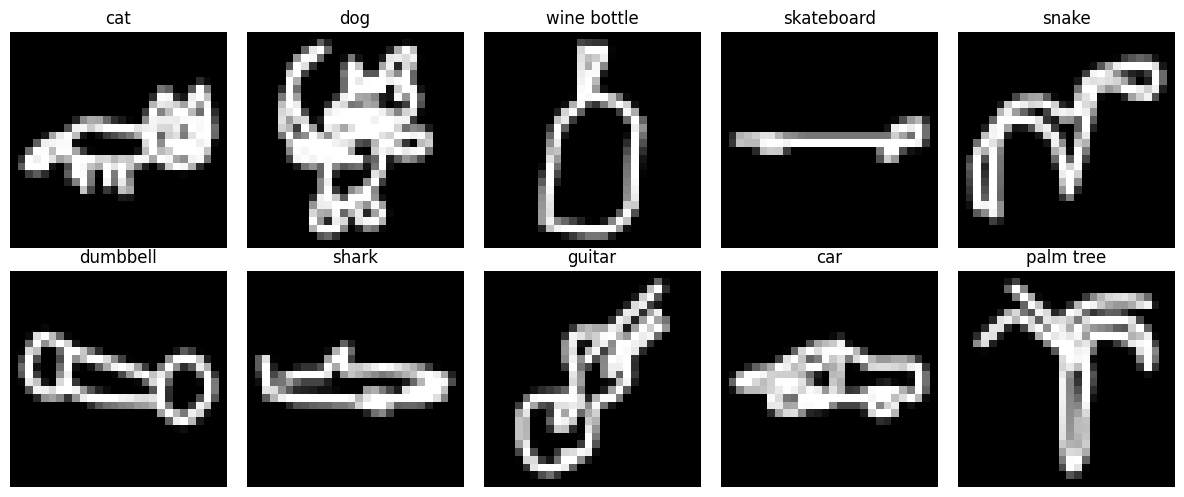

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, class_name in enumerate(classes):
    data = np.load(data_dir / f"{class_name}.npy")

    random_index = np.random.randint(len(data))
    image = data[random_index].reshape(28, 28)

    ax = axes.flat[i]
    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
TRAIN_PER_CLASS = 6000
CV_PER_CLASS = 2000
TEST_PER_CLASS = 2000

X_train, y_train = [], []
X_cv, y_cv = [], []
X_test, y_test = [], []

rng = np.random.default_rng(42)

for class_index, class_name in enumerate(classes):
    data = np.load(data_dir / f"{class_name}.npy")

    # Randomly choose 10,000 unique drawings from this class
    indices = rng.choice(
        len(data),
        size=TRAIN_PER_CLASS + CV_PER_CLASS + TEST_PER_CLASS,
        replace=False
    )

    selected = data[indices]

    train_data = selected[:TRAIN_PER_CLASS]
    cv_data = selected[TRAIN_PER_CLASS:TRAIN_PER_CLASS + CV_PER_CLASS]
    test_data = selected[TRAIN_PER_CLASS + CV_PER_CLASS:]

    X_train.append(train_data)
    y_train.append(np.full(TRAIN_PER_CLASS, class_index))

    X_cv.append(cv_data)
    y_cv.append(np.full(CV_PER_CLASS, class_index))

    X_test.append(test_data)
    y_test.append(np.full(TEST_PER_CLASS, class_index))

# Combine all 10 classes
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

X_cv = np.concatenate(X_cv)
y_cv = np.concatenate(y_cv)

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

print("Training:", X_train.shape, y_train.shape)
print("CV:      ", X_cv.shape, y_cv.shape)
print("Test:    ", X_test.shape, y_test.shape)

Training: (60000, 784) (60000,)
CV:       (20000, 784) (20000,)
Test:     (20000, 784) (20000,)


In [8]:
train_order = rng.permutation(len(X_train))
cv_order = rng.permutation(len(X_cv))
test_order = rng.permutation(len(X_test))

X_train = X_train[train_order]
y_train = y_train[train_order]

X_cv = X_cv[cv_order]
y_cv = y_cv[cv_order]

X_test = X_test[test_order]
y_test = y_test[test_order]

In [9]:
X_train = X_train.astype("float32") / 255.0
X_cv = X_cv.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Pixel range:")
print("Train:", X_train.min(), "to", X_train.max())
print("CV:   ", X_cv.min(), "to", X_cv.max())
print("Test: ", X_test.min(), "to", X_test.max())

Pixel range:
Train: 0.0 to 1.0
CV:    0.0 to 1.0
Test:  0.0 to 1.0


In [10]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow version:", tf.__version__)

/Users/seanandrews/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0


In [11]:
tf.random.set_seed(42)

model = Sequential([
    tf.keras.Input(shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="linear")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_cv, y_cv),
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6644 - loss: 1.0564 - val_accuracy: 0.8044 - val_loss: 0.6419
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8152 - loss: 0.5981 - val_accuracy: 0.8229 - val_loss: 0.5806
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8395 - loss: 0.5201 - val_accuracy: 0.8317 - val_loss: 0.5550
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.4673 - val_accuracy: 0.8346 - val_loss: 0.5459
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8694 - loss: 0.4268 - val_accuracy: 0.8354 - val_loss: 0.5470
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8792 - loss: 0.3925 - val_accuracy: 0.8385 - val_loss: 0.5461
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8897 - loss: 0.3615 - val_accuracy: 0.8396 - val_loss: 0.5497
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8988 - loss: 0.3348 - val_accuracy: 0.

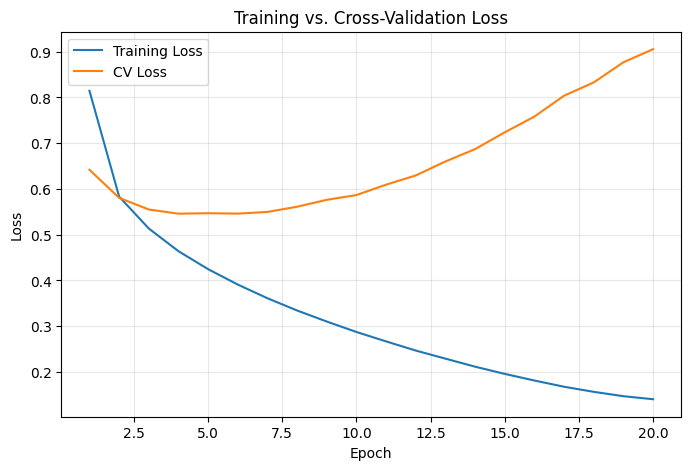

In [14]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="CV Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Cross-Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

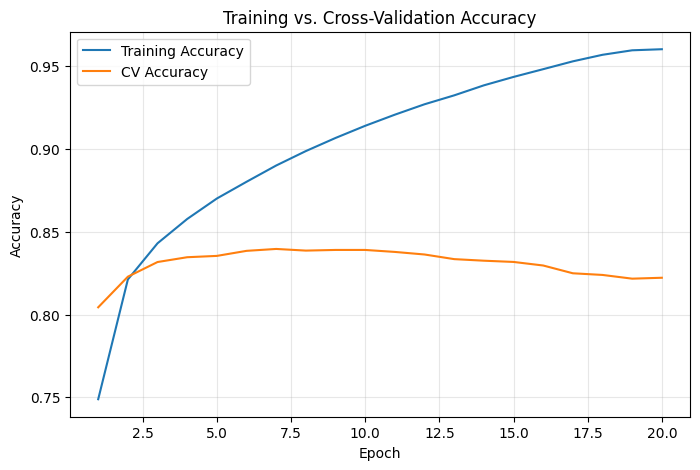

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="CV Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Cross-Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [16]:
final_train_loss = history.history["loss"][-1]
final_cv_loss = history.history["val_loss"][-1]

final_train_accuracy = history.history["accuracy"][-1]
final_cv_accuracy = history.history["val_accuracy"][-1]

best_cv_loss_epoch = np.argmin(history.history["val_loss"]) + 1
best_cv_accuracy_epoch = np.argmax(history.history["val_accuracy"]) + 1

print(f"Final Training Loss:     {final_train_loss:.4f}")
print(f"Final CV Loss:           {final_cv_loss:.4f}")
print()
print(f"Final Training Accuracy: {final_train_accuracy:.2%}")
print(f"Final CV Accuracy:       {final_cv_accuracy:.2%}")
print()
print(f"Lowest CV Loss: Epoch {best_cv_loss_epoch}")
print(f"Highest CV Accuracy: Epoch {best_cv_accuracy_epoch}")

Final Training Loss:     0.1404
Final CV Loss:           0.9054

Final Training Accuracy: 96.03%
Final CV Accuracy:       82.23%

Lowest CV Loss: Epoch 4
Highest CV Accuracy: Epoch 7


In [17]:
tf.random.set_seed(42)

model_l2 = Sequential([
    tf.keras.Input(shape=(784,)),
    
    Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    
    Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    
    Dense(10, activation="linear")
])

model_l2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_l2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [19]:
history_l2 = model_l2.fit(
    X_train,
    y_train,
    validation_data=(X_cv, y_cv),
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6714 - loss: 1.2926 - val_accuracy: 0.8007 - val_loss: 0.8376
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8084 - loss: 0.7951 - val_accuracy: 0.8170 - val_loss: 0.7532
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8287 - loss: 0.7085 - val_accuracy: 0.8232 - val_loss: 0.7195
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8401 - loss: 0.6640 - val_accuracy: 0.8281 - val_loss: 0.6985
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8463 - loss: 0.6343 - val_accuracy: 0.8285 - val_loss: 0.6886
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8531 - loss: 0.6133 - val_accuracy: 0.8303 - val_loss: 0.6840
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8584 - loss: 0.5957 - val_accuracy: 0.8324 - val_loss: 0.6780
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8626 - loss: 0.5809 - val_accuracy: 0.

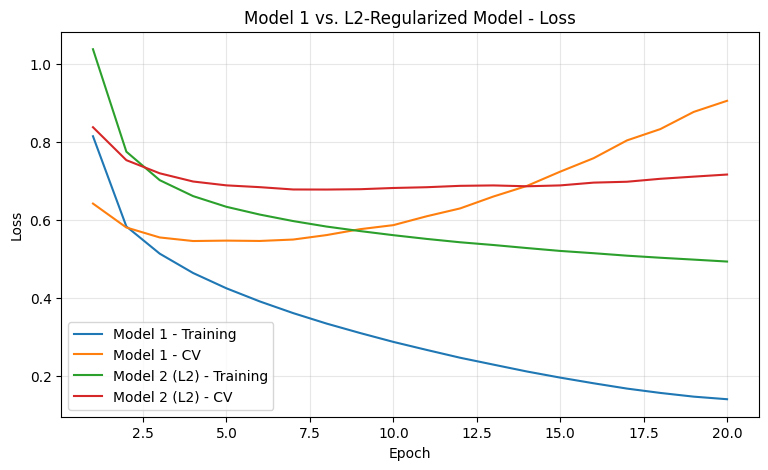

In [20]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(9, 5))

plt.plot(epochs, history.history["loss"], label="Model 1 - Training")
plt.plot(epochs, history.history["val_loss"], label="Model 1 - CV")

plt.plot(epochs, history_l2.history["loss"], label="Model 2 (L2) - Training")
plt.plot(epochs, history_l2.history["val_loss"], label="Model 2 (L2) - CV")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1 vs. L2-Regularized Model - Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

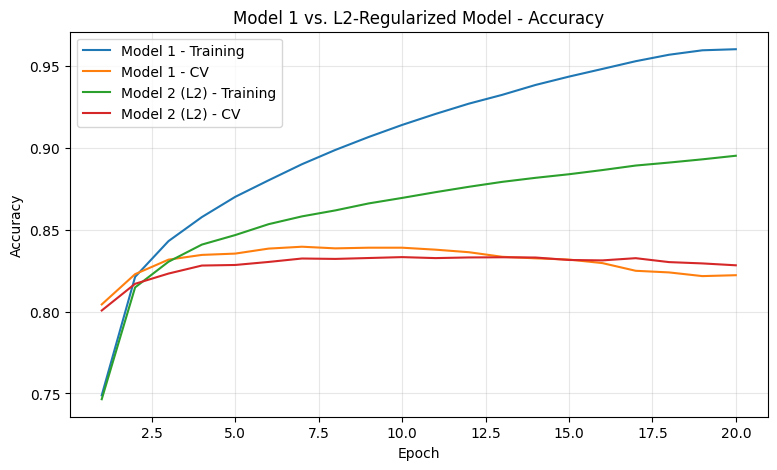

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(epochs, history.history["accuracy"], label="Model 1 - Training")
plt.plot(epochs, history.history["val_accuracy"], label="Model 1 - CV")

plt.plot(epochs, history_l2.history["accuracy"], label="Model 2 (L2) - Training")
plt.plot(epochs, history_l2.history["val_accuracy"], label="Model 2 (L2) - CV")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 1 vs. L2-Regularized Model - Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [22]:
best_l2_loss_epoch = np.argmin(history_l2.history["val_loss"]) + 1
best_l2_acc_epoch = np.argmax(history_l2.history["val_accuracy"]) + 1

best_l2_loss = np.min(history_l2.history["val_loss"])
best_l2_acc = np.max(history_l2.history["val_accuracy"])

print(f"Lowest CV Loss:     {best_l2_loss:.4f} at epoch {best_l2_loss_epoch}")
print(f"Highest CV Accuracy: {best_l2_acc:.2%} at epoch {best_l2_acc_epoch}")

Lowest CV Loss:     0.6779 at epoch 8
Highest CV Accuracy: 83.33% at epoch 10


In [23]:
LARGE_TRAIN_PER_CLASS = 20000

X_train_large, y_train_large = [], []

# Same seed used for the original split
rng_rebuild = np.random.default_rng(42)

for class_index, class_name in enumerate(classes):
    data = np.load(data_dir / f"{class_name}.npy")

    # Recreate the EXACT 10,000 indices selected originally
    original_indices = rng_rebuild.choice(
        len(data),
        size=10000,
        replace=False
    )

    # Original layout:
    # 0:6000     = training
    # 6000:8000  = CV
    # 8000:10000 = test
    original_train_indices = original_indices[:6000]
    cv_test_indices = original_indices[6000:10000]

    # Find examples that were NOT used anywhere in the original split
    all_indices = np.arange(len(data))
    unused_indices = np.setdiff1d(
        all_indices,
        original_indices,
        assume_unique=False
    )

    # Randomly select 14,000 additional examples
    extra_indices = rng_rebuild.choice(
        unused_indices,
        size=LARGE_TRAIN_PER_CLASS - 6000,
        replace=False
    )

    # Original 6,000 training examples + 14,000 new examples
    large_train_indices = np.concatenate([
        original_train_indices,
        extra_indices
    ])

    train_data = data[large_train_indices]

    X_train_large.append(train_data)
    y_train_large.append(
        np.full(LARGE_TRAIN_PER_CLASS, class_index)
    )

X_train_large = np.concatenate(X_train_large)
y_train_large = np.concatenate(y_train_large)

# Shuffle the 200,000 examples
shuffle_rng = np.random.default_rng(42)
shuffle_order = shuffle_rng.permutation(len(X_train_large))

X_train_large = X_train_large[shuffle_order]
y_train_large = y_train_large[shuffle_order]

# Normalize exactly like our original data
X_train_large = X_train_large.astype("float32") / 255.0

print("Large training set:", X_train_large.shape)
print("Labels:", y_train_large.shape)

Large training set: (200000, 784)
Labels: (200000,)


In [24]:
tf.random.set_seed(42)

model_3 = Sequential([
    tf.keras.Input(shape=(784,)),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    Dense(10, activation="linear")
])

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [26]:
history_3 = model_3.fit(
    X_train_large,
    y_train_large,
    validation_data=(X_cv, y_cv),
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7413 - loss: 1.0399 - val_accuracy: 0.8294 - val_loss: 0.6893
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8332 - loss: 0.6719 - val_accuracy: 0.8432 - val_loss: 0.6322
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8440 - loss: 0.6204 - val_accuracy: 0.8478 - val_loss: 0.6062
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8507 - loss: 0.5941 - val_accuracy: 0.8536 - val_loss: 0.5901
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8552 - loss: 0.5775 - val_accuracy: 0.8560 - val_loss: 0.5769
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8594 - loss: 0.5645 - val_accuracy: 0.8564 - val_loss: 0.5723
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8613 - loss: 0.5549 - val_accuracy: 0.8600 - val_loss: 0.5607
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8636 - loss: 0.5468 - 

In [27]:
best_3_loss_epoch = np.argmin(history_3.history["val_loss"]) + 1
best_3_acc_epoch = np.argmax(history_3.history["val_accuracy"]) + 1

best_3_loss = np.min(history_3.history["val_loss"])
best_3_acc = np.max(history_3.history["val_accuracy"])

print(f"Final Training Accuracy: {history_3.history['accuracy'][-1]:.2%}")
print(f"Final CV Accuracy:       {history_3.history['val_accuracy'][-1]:.2%}")
print()
print(f"Lowest CV Loss:          {best_3_loss:.4f} at epoch {best_3_loss_epoch}")
print(f"Highest CV Accuracy:     {best_3_acc:.2%} at epoch {best_3_acc_epoch}")

Final Training Accuracy: 87.46%
Final CV Accuracy:       86.68%

Lowest CV Loss:          0.5281 at epoch 20
Highest CV Accuracy:     86.92% at epoch 18


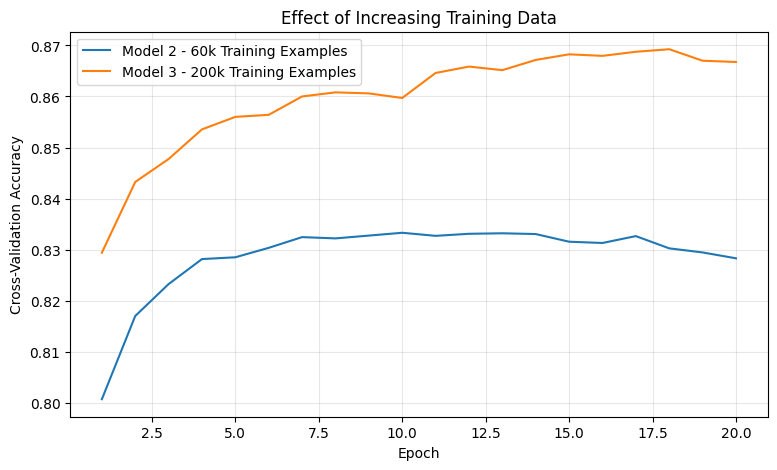

In [28]:
epochs = range(1, 21)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history_l2.history["val_accuracy"],
    label="Model 2 - 60k Training Examples"
)

plt.plot(
    epochs,
    history_3.history["val_accuracy"],
    label="Model 3 - 200k Training Examples"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Effect of Increasing Training Data")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

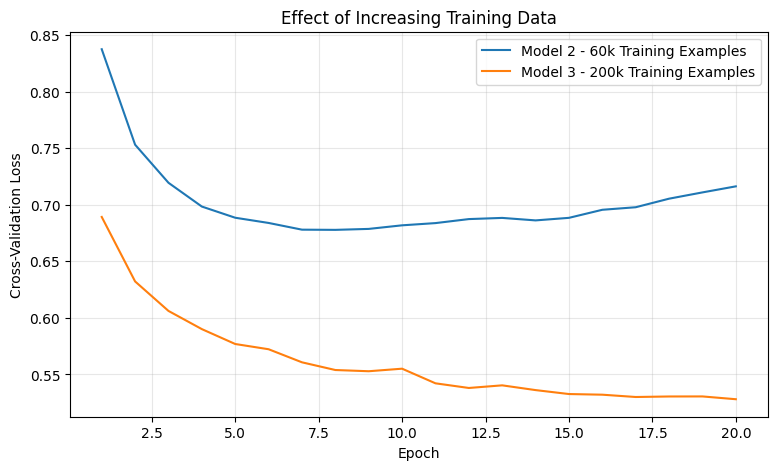

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history_l2.history["val_loss"],
    label="Model 2 - 60k Training Examples"
)

plt.plot(
    epochs,
    history_3.history["val_loss"],
    label="Model 3 - 200k Training Examples"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Validation Loss")
plt.title("Effect of Increasing Training Data")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [30]:
lambda_values = [0.0, 0.0001, 0.001, 0.01]

lambda_results = []
lambda_histories = {}
lambda_models = {}

for lambda_value in lambda_values:

    print("\n" + "=" * 50)
    print(f"Training model with lambda = {lambda_value}")
    print("=" * 50)

    tf.random.set_seed(42)

    model_lambda = Sequential([
        tf.keras.Input(shape=(784,)),

        Dense(
            128,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(lambda_value)
        ),

        Dense(
            64,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(lambda_value)
        ),

        Dense(10, activation="linear")
    ])

    model_lambda.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        ),
        metrics=["accuracy"]
    )

    history_lambda = model_lambda.fit(
        X_train_large,
        y_train_large,
        validation_data=(X_cv, y_cv),
        epochs=20,
        batch_size=128,
        verbose=0
    )

    best_epoch = np.argmax(
        history_lambda.history["val_accuracy"]
    )

    best_cv_accuracy = history_lambda.history[
        "val_accuracy"
    ][best_epoch]

    best_cv_loss = history_lambda.history[
        "val_loss"
    ][best_epoch]

    train_accuracy_at_best = history_lambda.history[
        "accuracy"
    ][best_epoch]

    lambda_results.append({
        "lambda": lambda_value,
        "best_epoch": best_epoch + 1,
        "train_accuracy": train_accuracy_at_best,
        "cv_accuracy": best_cv_accuracy,
        "cv_loss": best_cv_loss
    })

    lambda_histories[lambda_value] = history_lambda
    lambda_models[lambda_value] = model_lambda

    print(
        f"Best epoch: {best_epoch + 1} | "
        f"Train accuracy: {train_accuracy_at_best:.2%} | "
        f"CV accuracy: {best_cv_accuracy:.2%} | "
        f"CV loss: {best_cv_loss:.4f}"
    )


Training model with lambda = 0.0
Best epoch: 11 | Train accuracy: 90.75% | CV accuracy: 86.70% | CV loss: 0.4697

Training model with lambda = 0.0001
Best epoch: 10 | Train accuracy: 89.39% | CV accuracy: 86.83% | CV loss: 0.4965

Training model with lambda = 0.001
Best epoch: 15 | Train accuracy: 87.15% | CV accuracy: 86.65% | CV loss: 0.5335

Training model with lambda = 0.01
Best epoch: 20 | Train accuracy: 82.48% | CV accuracy: 83.08% | CV loss: 0.6724


In [31]:
print(
    f"{'Lambda':<12}"
    f"{'Best Epoch':<14}"
    f"{'Train Acc':<14}"
    f"{'CV Acc':<14}"
    f"{'CV Loss':<12}"
)

print("-" * 66)

for result in lambda_results:
    print(
        f"{result['lambda']:<12}"
        f"{result['best_epoch']:<14}"
        f"{result['train_accuracy']:<14.2%}"
        f"{result['cv_accuracy']:<14.2%}"
        f"{result['cv_loss']:<12.4f}"
    )

Lambda      Best Epoch    Train Acc     CV Acc        CV Loss     
------------------------------------------------------------------
0.0         11            90.75%        86.70%        0.4697      
0.0001      10            89.39%        86.83%        0.4965      
0.001       15            87.15%        86.65%        0.5335      
0.01        20            82.48%        83.08%        0.6724      


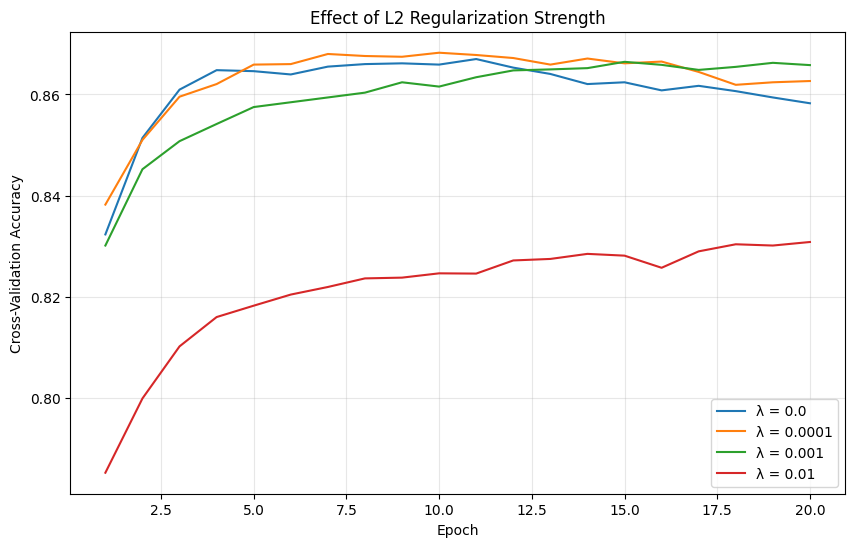

In [32]:
plt.figure(figsize=(10, 6))

for lambda_value in lambda_values:
    history_lambda = lambda_histories[lambda_value]

    plt.plot(
        range(1, 21),
        history_lambda.history["val_accuracy"],
        label=f"λ = {lambda_value}"
    )

plt.xlabel("Epoch")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Effect of L2 Regularization Strength")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

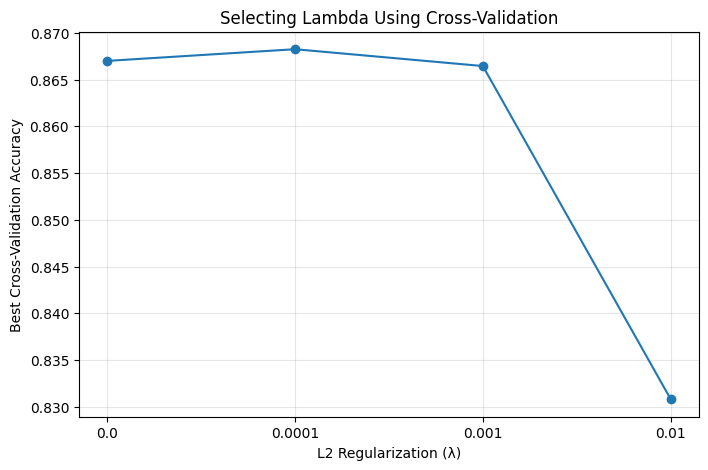

In [33]:
lambdas = [result["lambda"] for result in lambda_results]
best_accuracies = [
    result["cv_accuracy"] for result in lambda_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(lambdas)),
    best_accuracies,
    marker="o"
)

plt.xticks(
    range(len(lambdas)),
    [str(x) for x in lambdas]
)

plt.xlabel("L2 Regularization (λ)")
plt.ylabel("Best Cross-Validation Accuracy")
plt.title("Selecting Lambda Using Cross-Validation")
plt.grid(True, alpha=0.3)

plt.show()

In [34]:
X_train_cnn = X_train_large.reshape(-1, 28, 28, 1)
X_cv_cnn = X_cv.reshape(-1, 28, 28, 1)

print("CNN training shape:", X_train_cnn.shape)
print("CNN CV shape:", X_cv_cnn.shape)

CNN training shape: (200000, 28, 28, 1)
CNN CV shape: (20000, 28, 28, 1)


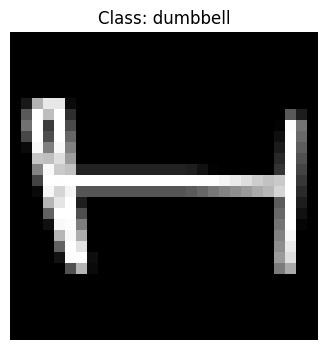

In [35]:
plt.figure(figsize=(4, 4))

plt.imshow(
    X_train_cnn[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Class: {classes[y_train_large[0]]}"
)

plt.axis("off")
plt.show()

In [36]:
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [37]:
tf.random.set_seed(42)

model_cnn = Sequential([

    tf.keras.Input(shape=(28, 28, 1)),

    # Learn simple local features such as edges and curves
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Learn more complex combinations of those features
    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert learned feature maps into a vector
    Flatten(),

    Dense(
        64,
        activation="relu"
    ),

    # 10 output logits — one per doodle class
    Dense(
        10,
        activation="linear"
    )
])

model_cnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

In [39]:
history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train_large,

    validation_data=(
        X_cv_cnn,
        y_cv
    ),

    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7788 - loss: 0.7191 - val_accuracy: 0.8856 - val_loss: 0.3798
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8949 - loss: 0.3462 - val_accuracy: 0.9053 - val_loss: 0.3103
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9129 - loss: 0.2830 - val_accuracy: 0.9166 - val_loss: 0.2738
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9230 - loss: 0.2457 - val_accuracy: 0.9215 - val_loss: 0.2536
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9318 - loss: 0.2192 - val_accuracy: 0.9244 - val_loss: 0.2424
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9380 - loss: 0.1983 - val_accuracy: 0.9255 - val_loss: 0.2372
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9426 - loss: 0.1804 - val_accuracy: 0.9266 - val_loss: 0.2386
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9472 -

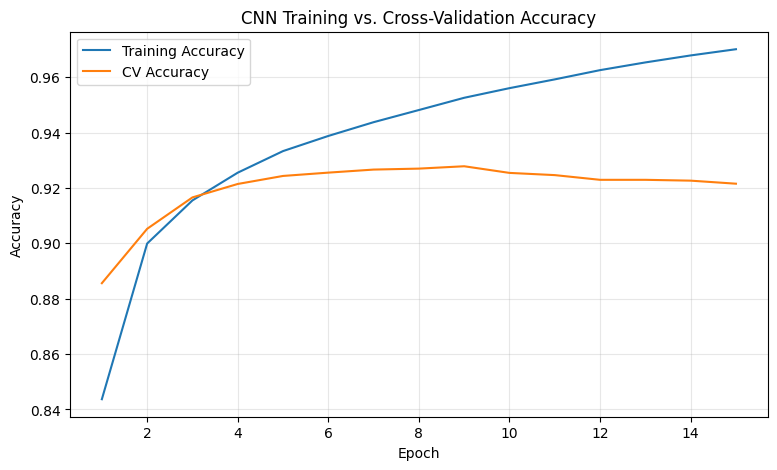

In [40]:
cnn_epochs = range(
    1,
    len(history_cnn.history["accuracy"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    cnn_epochs,
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_epochs,
    history_cnn.history["val_accuracy"],
    label="CV Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs. Cross-Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

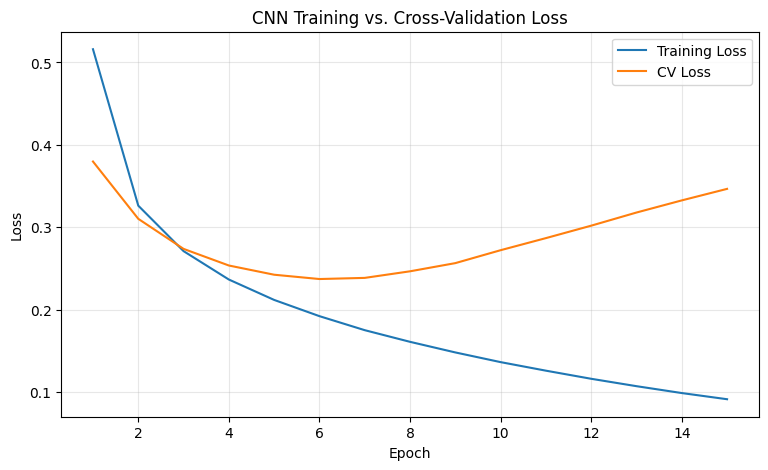

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    cnn_epochs,
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_epochs,
    history_cnn.history["val_loss"],
    label="CV Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs. Cross-Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [42]:
best_cnn_acc_epoch = (
    np.argmax(history_cnn.history["val_accuracy"]) + 1
)

best_cnn_loss_epoch = (
    np.argmin(history_cnn.history["val_loss"]) + 1
)

best_cnn_accuracy = np.max(
    history_cnn.history["val_accuracy"]
)

best_cnn_loss = np.min(
    history_cnn.history["val_loss"]
)

print(
    f"Highest CV Accuracy: "
    f"{best_cnn_accuracy:.2%} "
    f"at epoch {best_cnn_acc_epoch}"
)

print(
    f"Lowest CV Loss: "
    f"{best_cnn_loss:.4f} "
    f"at epoch {best_cnn_loss_epoch}"
)

Highest CV Accuracy: 92.79% at epoch 9
Lowest CV Loss: 0.2372 at epoch 6


In [43]:
dense_best_accuracy = max(
    result["cv_accuracy"]
    for result in lambda_results
)

print("MODEL COMPARISON")
print("-" * 40)

print(
    f"Best Dense NN CV Accuracy: "
    f"{dense_best_accuracy:.2%}"
)

print(
    f"CNN CV Accuracy:           "
    f"{best_cnn_accuracy:.2%}"
)

improvement = (
    best_cnn_accuracy - dense_best_accuracy
) * 100

print(
    f"CNN Improvement:           "
    f"{improvement:+.2f} percentage points"
)

MODEL COMPARISON
----------------------------------------
Best Dense NN CV Accuracy: 86.83%
CNN CV Accuracy:           92.79%
CNN Improvement:           +5.96 percentage points


In [44]:
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
tf.random.set_seed(42)

final_model = Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Flatten(),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        10,
        activation="linear"
    )
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

In [46]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [47]:
history_final = final_model.fit(
    X_train_cnn,
    y_train_large,

    validation_data=(
        X_cv_cnn,
        y_cv
    ),

    epochs=20,
    batch_size=128,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7803 - loss: 0.7197 - val_accuracy: 0.8911 - val_loss: 0.3700
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8961 - loss: 0.3405 - val_accuracy: 0.9099 - val_loss: 0.3037
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9142 - loss: 0.2771 - val_accuracy: 0.9191 - val_loss: 0.2707
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9253 - loss: 0.2406 - val_accuracy: 0.9238 - val_loss: 0.2530
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9325 - loss: 0.2162 - val_accuracy: 0.9248 - val_loss: 0.2465
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9375 - loss: 0.1982 - val_accuracy: 0.9266 - val_loss: 0.2421
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9420 - loss: 0.1832 - val_accuracy: 0.9267 - val_loss: 0.2403
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9454 -

In [48]:
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("Test shape:", X_test_cnn.shape)

Test shape: (20000, 28, 28, 1)


In [49]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print()
print(f"Final Test Accuracy: {test_accuracy:.2%}")
print(f"Final Test Loss:     {test_loss:.4f}")

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9248 - loss: 0.2427

Final Test Accuracy: 92.68%
Final Test Loss:     0.2352


In [50]:
test_logits = final_model.predict(
    X_test_cnn,
    verbose=1
)

test_probabilities = tf.nn.softmax(
    test_logits,
    axis=1
).numpy()

y_pred = np.argmax(
    test_probabilities,
    axis=1
)

print("Predictions:", y_pred.shape)
print("Actual labels:", y_test.shape)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predictions: (20000,)
Actual labels: (20000,)


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1677  262    3    5    6   18    3   12    5    9]
 [ 143 1714    3   10    8   31   22   11   30   28]
 [   7    8 1899    1    6   21    2   41    2   13]
 [   2    8    1 1913   14   25   13    3   20    1]
 [  12   24    4   11 1866   29   14   24    8    8]
 [  23   57   14    9   16 1818    4   21   20   18]
 [  25   41    1   10   19   15 1862    6   11   10]
 [   6    8    8    6   13   15    3 1931    5    5]
 [   7   31    1   16    6   14    5    7 1910    3]
 [   6   18    7    1    8   11    2    1    0 1946]]


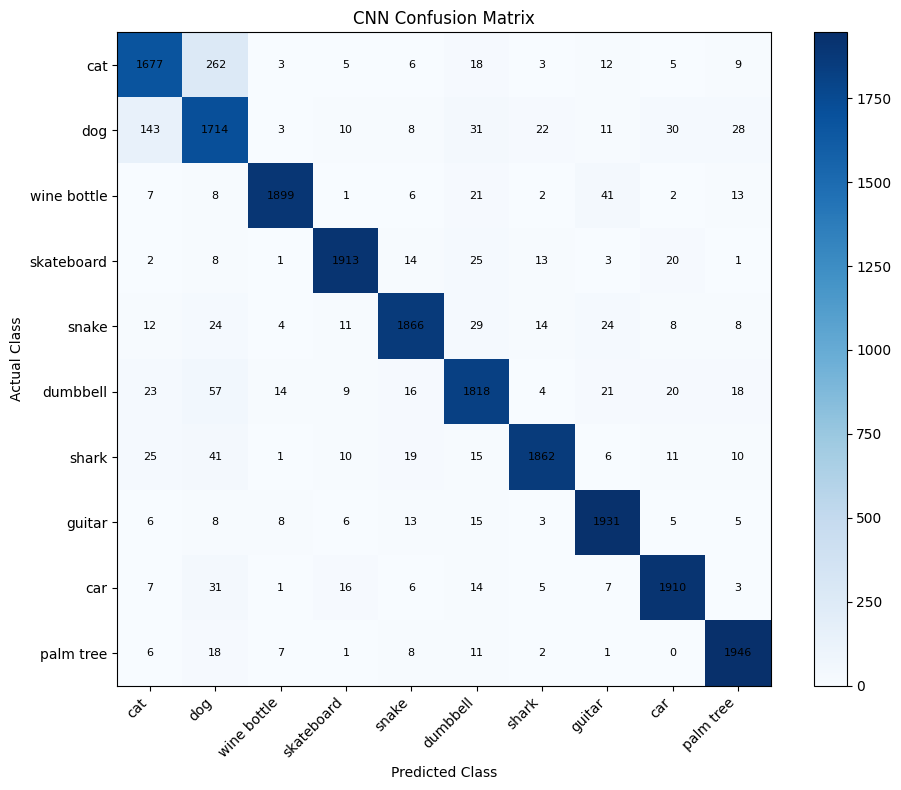

In [52]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [53]:
class_accuracies = (
    cm.diagonal() / cm.sum(axis=1)
)

print("PER-CLASS TEST ACCURACY")
print("-" * 35)

for class_name, accuracy in zip(
    classes,
    class_accuracies
):
    print(
        f"{class_name:<15} {accuracy:.2%}"
    )

PER-CLASS TEST ACCURACY
-----------------------------------
cat             83.85%
dog             85.70%
wine bottle     94.95%
skateboard      95.65%
snake           93.30%
dumbbell        90.90%
shark           93.10%
guitar          96.55%
car             95.50%
palm tree       97.30%


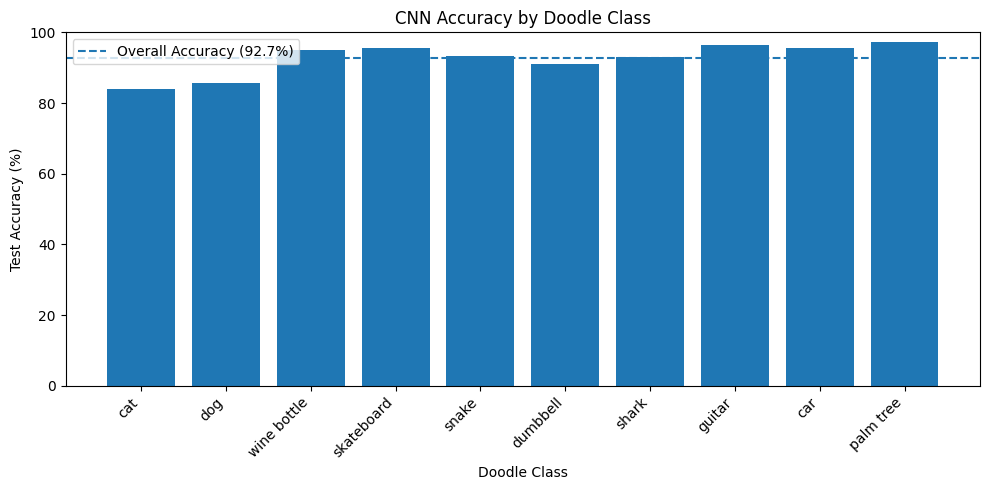

In [54]:
plt.figure(figsize=(10, 5))

plt.bar(
    classes,
    class_accuracies * 100
)

plt.axhline(
    y=test_accuracy * 100,
    linestyle="--",
    label=f"Overall Accuracy ({test_accuracy:.1%})"
)

plt.xlabel("Doodle Class")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN Accuracy by Doodle Class")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

In [55]:
final_model.save("../models/doodle_classifier.keras")

print("Final model saved!")

Final model saved!


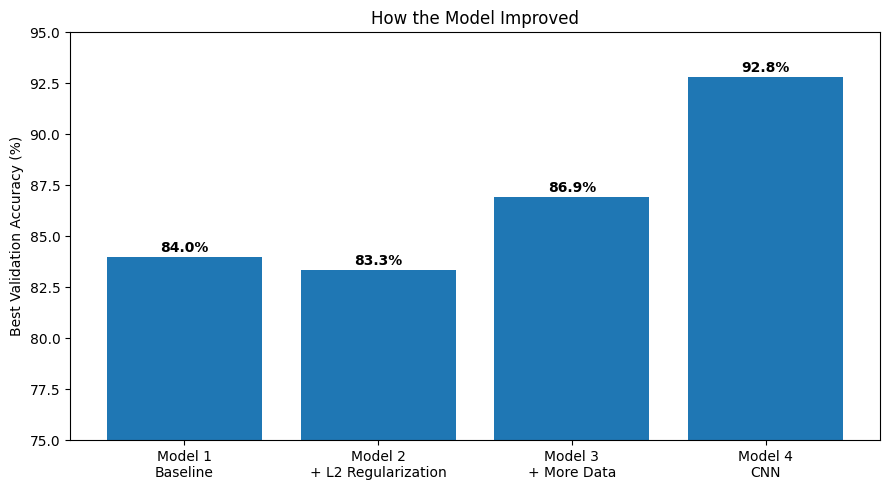

MODEL PROGRESSION
----------------------------------------
Model 1 Baseline: 83.96%
Model 2 + L2 Regularization: 83.33%
Model 3 + More Data: 86.92%
Model 4 CNN: 92.79%


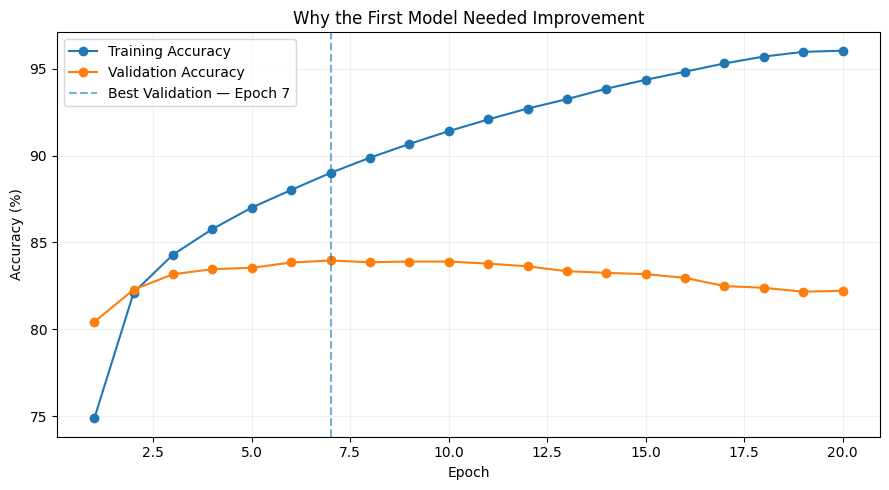


MODEL 1
----------------------------------------
Best validation accuracy: 83.96%
Best validation epoch: 7
Final training accuracy: 96.03%
Final validation accuracy: 82.23%


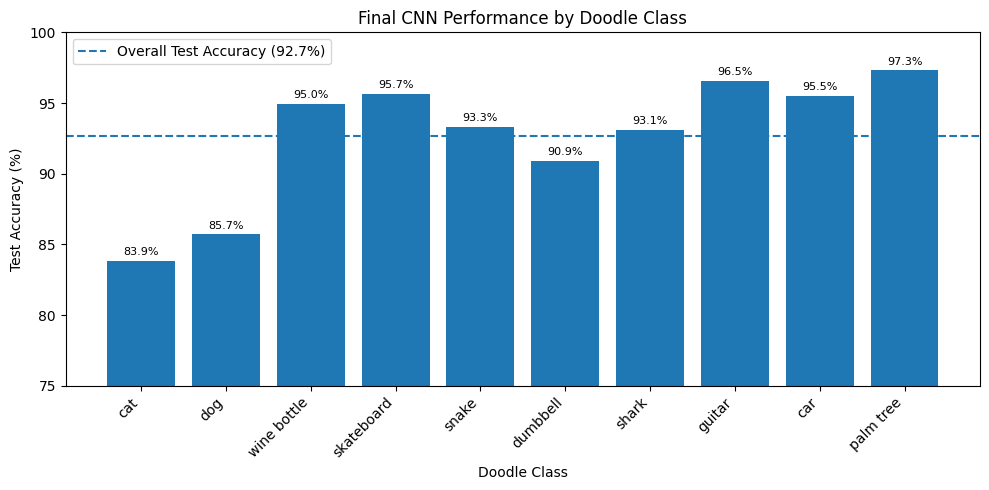


FINAL TEST RESULTS
----------------------------------------
Overall test accuracy: 92.68%

cat             83.85%
dog             85.70%
wine bottle     94.95%
skateboard      95.65%
snake           93.30%
dumbbell        90.90%
shark           93.10%
guitar          96.55%
car             95.50%
palm tree       97.30%


In [58]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# GRAPH 1 — MODEL PROGRESSION
# ============================================================

model_1_best = np.max(history.history["val_accuracy"]) * 100
model_2_best = np.max(history_l2.history["val_accuracy"]) * 100
model_3_best = np.max(history_3.history["val_accuracy"]) * 100
cnn_best = np.max(history_cnn.history["val_accuracy"]) * 100

model_names = [
    "Model 1\nBaseline",
    "Model 2\n+ L2 Regularization",
    "Model 3\n+ More Data",
    "Model 4\nCNN"
]

model_accuracies = [
    model_1_best,
    model_2_best,
    model_3_best,
    cnn_best
]

plt.figure(figsize=(9, 5))

bars = plt.bar(model_names, model_accuracies)

plt.ylabel("Best Validation Accuracy (%)")
plt.title("How the Model Improved")
plt.ylim(75, 95)

for bar, value in zip(bars, model_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.25,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("MODEL PROGRESSION")
print("-" * 40)

for name, accuracy in zip(model_names, model_accuracies):
    print(f"{name.replace(chr(10), ' ')}: {accuracy:.2f}%")


# ============================================================
# GRAPH 2 — MODEL 1: TRAINING VS. VALIDATION
# ============================================================

train_accuracy = np.array(
    history.history["accuracy"]
) * 100

validation_accuracy = np.array(
    history.history["val_accuracy"]
) * 100

epochs = np.arange(1, len(train_accuracy) + 1)

best_epoch = np.argmax(validation_accuracy) + 1
best_validation = np.max(validation_accuracy)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    validation_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    alpha=0.6,
    label=f"Best Validation — Epoch {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Why the First Model Needed Improvement")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\nMODEL 1")
print("-" * 40)
print(f"Best validation accuracy: {best_validation:.2f}%")
print(f"Best validation epoch: {best_epoch}")
print(f"Final training accuracy: {train_accuracy[-1]:.2f}%")
print(f"Final validation accuracy: {validation_accuracy[-1]:.2f}%")


# ============================================================
# GRAPH 3 — FINAL CNN PERFORMANCE BY CLASS
# class_accuracies is ALREADY stored as percentages
# ============================================================

class_accuracy_percent = np.array(class_accuracies)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    classes,
    class_accuracy_percent
)

overall_test_percent = test_accuracy * 100

plt.axhline(
    overall_test_percent,
    linestyle="--",
    label=f"Overall Test Accuracy ({overall_test_percent:.1f}%)"
)

for bar, value in zip(bars, class_accuracy_percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.4,
        f"{value:.1f}%",
        ha="center",
        fontsize=8
    )

plt.xlabel("Doodle Class")
plt.ylabel("Test Accuracy (%)")
plt.title("Final CNN Performance by Doodle Class")

plt.xticks(rotation=45, ha="right")

# Zoom in so differences between classes are easier to see
plt.ylim(75, 100)

plt.legend()
plt.tight_layout()
plt.show()

print("\nFINAL TEST RESULTS")
print("-" * 40)
print(f"Overall test accuracy: {overall_test_percent:.2f}%\n")

for class_name, accuracy in zip(classes, class_accuracy_percent):
    print(f"{class_name:<15} {accuracy:.2f}%")